# Pracownia 5

## Imports

In [14]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

## Zadanie 1


In [3]:
# Wczytanie danych - plik CH06PR15.txt
# Kolumny: 1: wiek, 2: ciężkość choroby, 3: poziom niepokoju, 4: satysfakcja
data = pd.read_csv('../data/CH06PR15.txt', sep='\s+', header=None)
data.columns = ['wiek', 'choroba', 'niepokoj', 'satysfakcja']

y = data['satysfakcja'].values
X_orig = data[['wiek', 'choroba', 'niepokoj']].values
X = np.column_stack([np.ones(X_orig.shape[0]), X_orig]) # Dodanie kolumny jedynek

n, p = X.shape # n - liczba obserwacji, p - liczba parametrów (w tym beta0)

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_22360/1909566809.py:3: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv('../data/CH06PR15.txt', sep='\s+', header=None)


In [4]:
# 1. Wzory teoretyczne z tablicy
beta_hat_theoretical = np.linalg.inv(X.T @ X) @ X.T @ y

# 2. Polecenia wbudowane
model = sm.OLS(y, X).fit()
beta_hat_builtin = model.params

print("Równanie regresji:")
print(f"Y = {beta_hat_theoretical[0]:.4f} + ({beta_hat_theoretical[1]:.4f})*wiek + "
      f"({beta_hat_theoretical[2]:.4f})*choroba + ({beta_hat_theoretical[3]:.4f})*niepokoj")

df_beta = pd.DataFrame({
    'Teoretyczne (Tablica)': beta_hat_theoretical,
    'Wbudowane (statsmodels)': beta_hat_builtin
}, index=['Intercept', 'wiek', 'choroba', 'niepokoj'])
print("\nPorównanie estymatorów:")
print(df_beta.to_markdown())

Równanie regresji:
Y = 1.0532 + (-0.0059)*wiek + (0.0019)*choroba + (0.0301)*niepokoj

Porównanie estymatorów:
|           |   Teoretyczne (Tablica) |   Wbudowane (statsmodels) |
|:----------|------------------------:|--------------------------:|
| Intercept |              1.05325    |                1.05325    |
| wiek      |             -0.00586051 |               -0.00586051 |
| choroba   |              0.00192805 |                0.00192805 |
| niepokoj  |              0.0301477  |                0.0301477  |


In [5]:
y_mean = np.mean(y)
y_hat = X @ beta_hat_theoretical
sse_theo = np.sum((y - y_hat)**2)                # SSE = ||Y - Y_hat||^2
ssto_theo = np.sum((y - y_mean)**2)              # SSTO = suma kwadratów całkowita
ssr_theo = ssto_theo - sse_theo                  # SSR = suma kwadratów regresji

r2_theo = ssr_theo / ssto_theo                   # R^2 = SSR / SSTO
df1 = p - 1                                      # Stopnie swobody licznika (3)
df2 = n - p                                      # Stopnie swobody mianownika (42)
f_stat_theo = (ssr_theo / df1) / (sse_theo / df2)
p_val_theo = 1 - stats.f.cdf(f_stat_theo, df1, df2)

results_b = pd.DataFrame({
    'Teoretyczne (Tablica)': [r2_theo, f_stat_theo, p_val_theo],
    'Wbudowane (statsmodels)': [model.rsquared, model.fvalue, model.f_pvalue]
}, index=['R-kwadrat (R^2)', 'Statystyka F', 'p-wartość'])

print(f"Stopnie swobody: df1 = {df1}, df2 = {df2}")
print(results_b.to_markdown())

Stopnie swobody: df1 = 3, df2 = 42
|                 |   Teoretyczne (Tablica) |   Wbudowane (statsmodels) |
|:----------------|------------------------:|--------------------------:|
| R-kwadrat (R^2) |             0.541548    |               0.541548    |
| Statystyka F    |            16.5376      |              16.5376      |
| p-wartość       |             3.04311e-07 |               3.04311e-07 |


In [13]:
s2 = sse_theo / df2
v_beta = s2 * np.linalg.inv(X.T @ X)
se_beta_theo = np.sqrt(np.diag(v_beta))

t_stats_theo = beta_hat_theoretical / se_beta_theo

p_values_theo = 2 * (1 - stats.t.cdf(np.abs(t_stats_theo), df=df2))

t_crit = stats.t.ppf(0.975, df=df2)
ci_low_theo = beta_hat_theoretical - t_crit * se_beta_theo
ci_high_theo = beta_hat_theoretical + t_crit * se_beta_theo

t_stats_builtin = model.tvalues
p_values_builtin = model.pvalues
conf_int_builtin = model.conf_int(alpha=0.05)

labels = ['Intercept', 'Wiek', 'Choroba', 'Niepokój']

results_c = pd.DataFrame({
    'Parametr': labels,
    'Beta (Estymator)': beta_hat_theoretical,
    'T-stat (Teor.)': t_stats_theo,
    'T-stat (Wbud.)': t_stats_builtin,
    'p-val (Teor.)': p_values_theo,
    'p-val (Wbud.)': p_values_builtin,
    'CI 95% Dolny (Teor.)': ci_low_theo,
    'CI 95% Górny (Teor.)': ci_high_theo,
    'CI 95% Dolny (Wbud.)': conf_int_builtin[:, 0],
    'CI 95% Górny (Wbud.)': conf_int_builtin[:, 1]
})

print(results_c.to_markdown(index=False))

| Parametr   |   Beta (Estymator) |   T-stat (Teor.) |   T-stat (Wbud.) |   p-val (Teor.) |   p-val (Wbud.) |   CI 95% Dolny (Teor.) |   CI 95% Górny (Teor.) |   CI 95% Dolny (Wbud.) |   CI 95% Górny (Wbud.) |
|:-----------|-------------------:|-----------------:|-----------------:|----------------:|----------------:|-----------------------:|-----------------------:|-----------------------:|-----------------------:|
| Intercept  |         1.05325    |         1.71597  |         1.71597  |      0.0935371  |      0.0935371  |            -0.185436   |            2.29193     |            -0.185436   |            2.29193     |
| Wiek       |        -0.00586051 |        -1.8973   |        -1.8973   |      0.0646781  |      0.0646781  |            -0.0120941  |            0.000373089 |            -0.0120941  |            0.000373089 |
| Choroba    |         0.00192805 |         0.333188 |         0.333188 |      0.74065    |      0.74065    |            -0.00974994 |            0.013606    | 

<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_22360/2257326144.py:12: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Przewidywana Satysfakcja ($\hat{Y}$)')


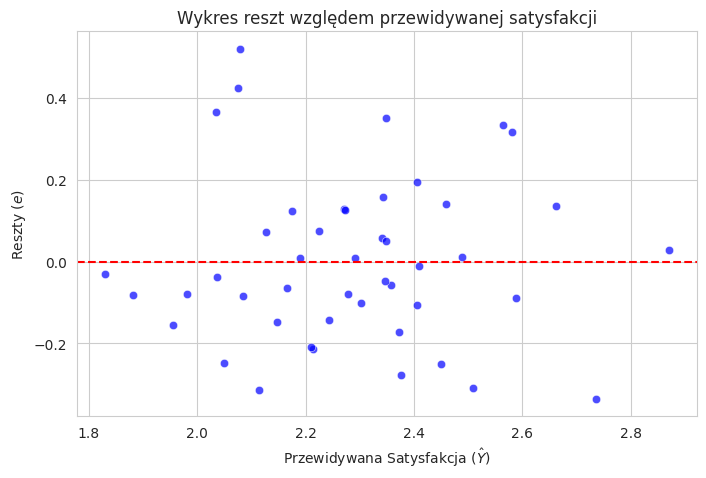

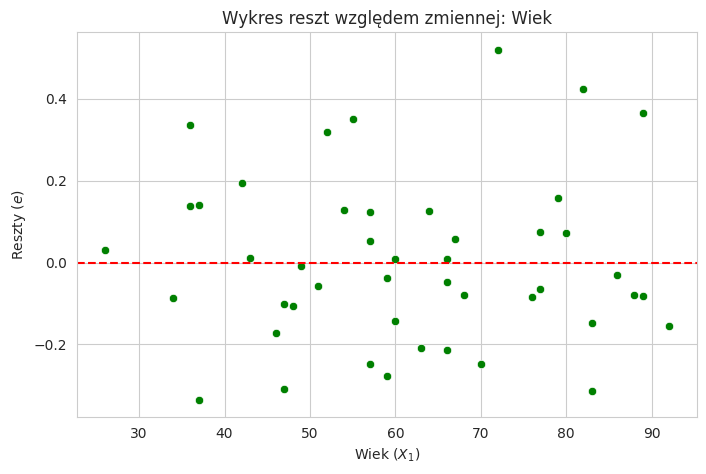

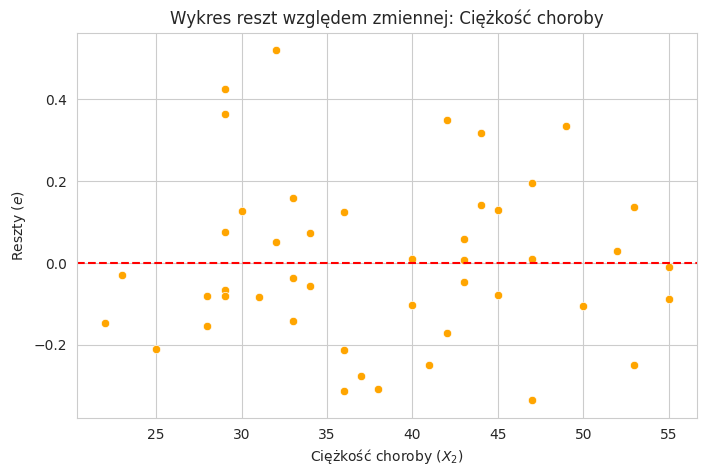

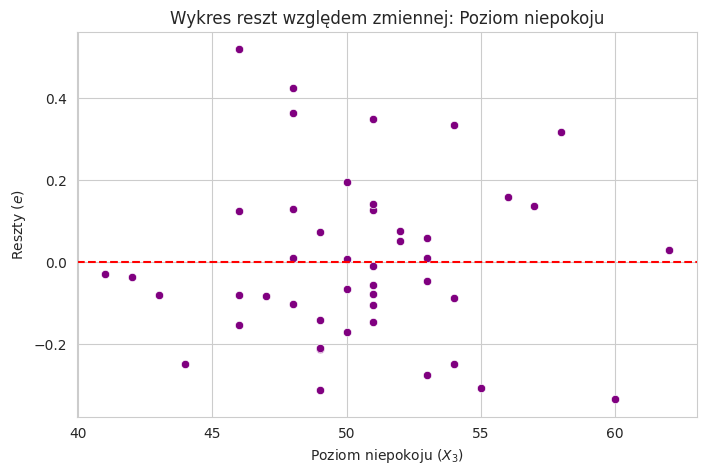

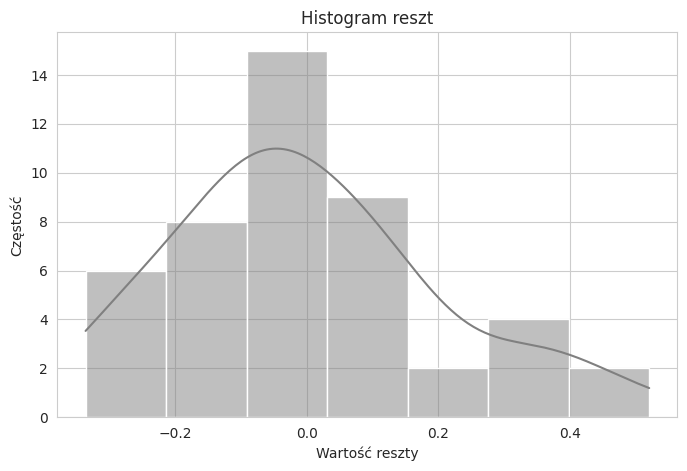

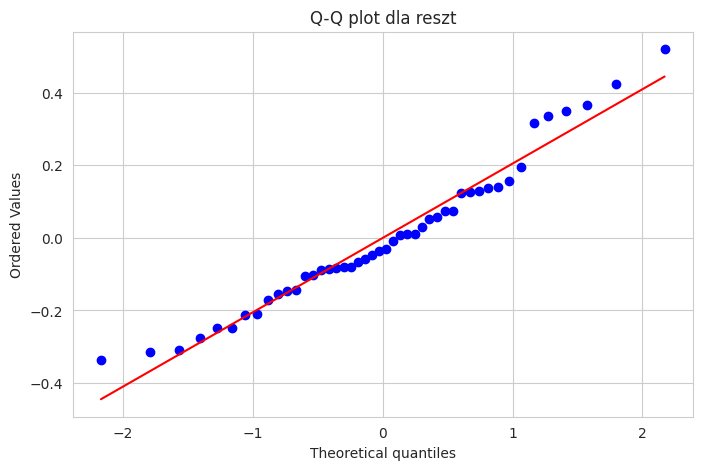

Statystyka testowa ($W$): 0.9629
p-wartość: 0.1481


In [18]:
y_hat = X @ beta_hat_theoretical
reszty = y - y_hat

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_hat, y=reszty, color='blue', alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Wykres reszt względem przewidywanej satysfakcji')
plt.xlabel('Przewidywana Satysfakcja ($\hat{Y}$)')
plt.ylabel('Reszty ($e$)')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=data['wiek'], y=reszty, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title('Wykres reszt względem zmiennej: Wiek')
plt.xlabel('Wiek ($X_1$)')
plt.ylabel('Reszty ($e$)')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=data['choroba'], y=reszty, color='orange')
plt.axhline(0, color='red', linestyle='--')
plt.title('Wykres reszt względem zmiennej: Ciężkość choroby')
plt.xlabel('Ciężkość choroby ($X_2$)')
plt.ylabel('Reszty ($e$)')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=data['niepokoj'], y=reszty, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title('Wykres reszt względem zmiennej: Poziom niepokoju')
plt.xlabel('Poziom niepokoju ($X_3$)')
plt.ylabel('Reszty ($e$)')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(reszty, kde=True, color='gray')
plt.title('Histogram reszt')
plt.xlabel('Wartość reszty')
plt.ylabel('Częstość')
plt.show()

plt.figure(figsize=(8, 5))
stats.probplot(reszty, dist="norm", plot=plt)
plt.title('Q-Q plot dla reszt')
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(reszty)
print(f"Statystyka testowa ($W$): {shapiro_stat:.4f}")
print(f"p-wartość: {shapiro_p:.4f}")

In [24]:
# Model zredukowany: Y = beta0 + beta1*wiek
X_red = X[:, :2]  # Intercept + Wiek
model_red = sm.OLS(y, X_red).fit()

sse_full = np.sum((y - model.fittedvalues)**2)
sse_red = np.sum((y - model_red.fittedvalues)**2)

n = X.shape[0]
p_full = X.shape[1]
p_red = X_red.shape[1]

df_num_theo = p_full - p_red
df_den_theo = n - p_full

f_stat_theo = ((sse_red - sse_full) / df_num_theo) / (sse_full / df_den_theo)
p_val_theo = 1 - stats.f.cdf(f_stat_theo, df_num_theo, df_den_theo)

R = np.array([[0, 0, 1, 0], [0, 0, 0, 1]])
f_test_builtin = model.f_test(R)

# --- 4. PREZENTACJA WYNIKÓW ---
results_e = pd.DataFrame({
    'Metryka': ['Statystyka F', 'p-wartość', 'df1', 'df2'],
    'Teoretyczne': [f_stat_theo, p_val_theo, df_num_theo, df_den_theo],
    'Wbudowane': [
        float(f_test_builtin.fvalue),
        float(f_test_builtin.pvalue),
        int(f_test_builtin.df_num),
        int(f_test_builtin.df_denom)
    ]
})

print(results_e.to_markdown(index=False))

| Metryka      |   Teoretyczne |   Wbudowane |
|:-------------|--------------:|------------:|
| Statystyka F |    5.77392    |  5.77392    |
| p-wartość    |    0.00609051 |  0.00609051 |
| df1          |    2          |  2          |
| df2          |   42          | 42          |


## Zadanie 2

In [5]:
n = 1000
p_total = 950
sigma_x = 0.1

# a) Generowanie macierzy X i wektora beta
np.random.seed(42)
X = np.random.normal(0, sigma_x, size=(n, p_total))

beta_true = np.zeros(p_total)
beta_true[:5] = 3  # beta = (3, 3, 3, 3, 3, 0, ..., 0)

epsilon = np.random.normal(0, 1, size=n)
Y = X @ beta_true + epsilon

In [6]:
def run_regression(X_subset, Y, k, true_beta_subset):
    n_obs = X_subset.shape[0]

    # Estymacja beta (wzór z tablicy)
    xtx_inv = np.linalg.inv(X_subset.T @ X_subset)
    beta_hat = xtx_inv @ X_subset.T @ Y
    Y_hat = X_subset @ beta_hat

    # SSE i MSE (wzory z tablicy)
    sse = np.sum((Y - Y_hat)**2)
    # MSE = ||X*beta_hat - X*beta||^2
    mse = np.sum((X_subset @ (beta_hat - true_beta_subset))**2)

    # AIC
    aic = n_obs * np.log(sse / n_obs) + 2 * k

    # Testy T i p-wartości
    s2 = sse / (n_obs - k)
    se_beta = np.sqrt(s2 * np.diag(xtx_inv))
    t_stats = beta_hat / se_beta
    # p = 2(1 - F(|T|))
    p_vals = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n_obs - k))

    return sse, mse, aic, p_vals, beta_hat

k_list = [1, 2, 5, 10, 50, 100, 500, 950]

In [9]:
# b) Pierwsze k kolumn [cite: 23]
results_b = []
for k in k_list:
    indices = np.arange(k)
    sse, mse, aic, p_vals, _ = run_regression(X[:, indices], Y, k, beta_true[indices])

    # Fałszywe odkrycia (FD): odrzucenie H0 dla zmiennych o beta=0 (indeksy >= 5)
    fd = np.sum(p_vals[5:] < 0.05) if k > 5 else 0
    p1 = p_vals[0] if k >= 1 else np.nan
    p2 = p_vals[1] if k >= 2 else np.nan

    results_b.append([k, sse, mse, aic, p1, p2, fd])

df_b = pd.DataFrame(results_b, columns=['k', 'SSE', 'MSE', 'AIC', 'p1', 'p2', 'FD'])

# c) Zmienne o największych współczynnikach [cite: 30]
# Estymujemy pełny model dla k=950, aby posortować zmienne
_, _, _, _, full_beta = run_regression(X, Y, 950, beta_true)
sorted_indices = np.argsort(np.abs(full_beta))[::-1]

results_c = []
for k in k_list:
    indices = sorted_indices[:k]
    sse, mse, aic, p_vals, _ = run_regression(X[:, indices], Y, k, beta_true[indices])

    # FD w punkcie c: p < 0.05 dla zmiennych, których prawdziwe beta wynosi 0
    fd = np.sum(p_vals[np.isin(indices, np.arange(5, 950))] < 0.05)

    results_c.append([k, sse, mse, aic, fd])

df_c = pd.DataFrame(results_c, columns=['k', 'SSE', 'MSE', 'AIC', 'FD'])

print("Wyniki punktu b (Pierwsze k kolumn):")
print(df_b.to_markdown(index=False))
print("\nWyniki punktu c (Top k współczynników):")
print(df_c.to_markdown(index=False))

Wyniki punktu b (Pierwsze k kolumn):
|   k |       SSE |       MSE |        AIC |          p1 |          p2 |   FD |
|----:|----------:|----------:|-----------:|------------:|------------:|-----:|
|   1 | 1381.98   |   2.70193 |   325.519  | 0           | nan         |    0 |
|   2 | 1261.51   |   2.88623 |   236.309  | 0           |   0         |    0 |
|   5 | 1012.41   |   5.07997 |    22.331  | 0           |   0         |    0 |
|  10 | 1007.88   |   9.60564 |    27.8508 | 0           |   0         |    0 |
|  50 |  959.852  |  57.6353  |    59.0239 | 0           |   0         |    3 |
| 100 |  916.862  | 100.625   |   113.202  | 0           |   0         |    4 |
| 500 |  512.026  | 505.461   |   330.62   | 0           |   8.074e-10 |   23 |
| 950 |   40.9714 | 976.516   | -1294.88   | 0.000108639 |   0.149241  |   51 |

Wyniki punktu c (Top k współczynników):
|   k |       SSE |       MSE |       AIC |   FD |
|----:|----------:|----------:|----------:|-----:|
|   1 | 1505.76   | 

In [15]:
num_reps = 1000
alpha = 0.05
k_values = [1, 2, 5, 10, 50, 100, 500, 950]

power_x1_b = {k: 0 for k in k_values}
power_x2_b = {k: 0 for k in k_values}
expected_fd_b = {k: 0 for k in k_values}
best_ks_b = []

power_x1_c = {k: 0 for k in k_values}
power_x2_c = {k: 0 for k in k_values}
expected_fd_c = {k: 0 for k in k_values}
best_ks_c = []

start_time = time.time()

for _ in range(num_reps):
    # Nowy wektor Y dla każdej iteracji
    eps_sim = np.random.normal(0, 1, size=n)
    Y_sim = X @ beta_true + eps_sim

    # --- PUNKT B (Pierwsze k kolumn) ---
    aics_b = []
    for k in k_values:
        indices = np.arange(k)
        sse, mse, aic, p_vals, b_hat = run_regression(X[:, indices], Y_sim, k, beta_true[indices])

        # Moc dla X1 i X2
        if k >= 1 and p_vals[0] <= alpha: power_x1_b[k] += 1
        if k >= 2 and p_vals[1] <= alpha: power_x2_b[k] += 1

        # Fałszywe odkrycia (indeksy >= 5 mają prawdziwe beta=0)
        if k > 5:
            expected_fd_b[k] += np.sum(p_vals[5:] <= alpha)

        aics_b.append(aic)
    best_ks_b.append(k_values[np.argmin(aics_b)])

    # --- PUNKT C (Największe oszacowane współczynniki) ---
    # 1. Estymacja pełnego modelu dla wyboru zmiennych
    _, _, _, _, full_beta_hat = run_regression(X, Y_sim, 950, beta_true)
    sorted_idx = np.argsort(np.abs(full_beta_hat))[::-1] # malejąco

    aics_c = []
    for k in k_values:
        indices = sorted_idx[:k]
        sse, mse, aic, p_vals, b_hat = run_regression(X[:, indices], Y_sim, k, beta_true[indices])

        # Moc: sprawdzamy czy X1 (indeks 0) i X2 (indeks 1) weszły do top k i czy są istotne
        if 0 in indices:
            pos1 = np.where(indices == 0)[0][0]
            if p_vals[pos1] <= alpha: power_x1_c[k] += 1
        if 1 in indices:
            pos2 = np.where(indices == 1)[0][0]
            if p_vals[pos2] <= alpha: power_x2_c[k] += 1

        # Fałszywe odkrycia: p <= alpha dla zmiennych o prawdziwym beta=0
        true_beta_zero_mask = (indices >= 5)
        expected_fd_c[k] += np.sum(p_vals[true_beta_zero_mask] <= alpha)

        aics_c.append(aic)
    best_ks_c.append(k_values[np.argmin(aics_c)])

# --- PRZYGOTOWANIE TABEL WYNIKOWYCH ---
data_b = [[k, power_x1_b[k]/num_reps, power_x2_b[k]/num_reps, expected_fd_b[k]/num_reps] for k in k_values]
df_final_b = pd.DataFrame(data_b, columns=['k', 'Moc X1', 'Moc X2', 'E(Fałszywe Odkrycia)'])

data_c = [[k, power_x1_c[k]/num_reps, power_x2_c[k]/num_reps, expected_fd_c[k]/num_reps] for k in k_values]
df_final_c = pd.DataFrame(data_c, columns=['k', 'Moc X1', 'Moc X2', 'E(Fałszywe Odkrycia)'])

print(df_final_b.to_markdown(index=False))
print(df_final_c.to_markdown(index=False))

print("\n--- PORÓWNANIE AIC ---")
print(f"Średni rozmiar modelu wybrany przez AIC (punkt b): {np.mean(best_ks_b):.2f}")
print(f"Średni rozmiar modelu wybrany przez AIC (punkt c): {np.mean(best_ks_c):.2f}")

|   k |   Moc X1 |   Moc X2 |   E(Fałszywe Odkrycia) |
|----:|---------:|---------:|-----------------------:|
|   1 |    1     |    0     |                  0     |
|   2 |    1     |    1     |                  0     |
|   5 |    1     |    1     |                  0     |
|  10 |    1     |    1     |                  0.232 |
|  50 |    1     |    1     |                  2.249 |
| 100 |    1     |    1     |                  4.781 |
| 500 |    1     |    1     |                 24.824 |
| 950 |    0.684 |    0.505 |                 47.364 |
|   k |   Moc X1 |   Moc X2 |   E(Fałszywe Odkrycia) |
|----:|---------:|---------:|-----------------------:|
|   1 |    0.064 |    0.106 |                  0.065 |
|   2 |    0.123 |    0.171 |                  0.141 |
|   5 |    0.23  |    0.249 |                  0.388 |
|  10 |    0.315 |    0.315 |                  0.848 |
|  50 |    0.592 |    0.555 |                  4.962 |
| 100 |    0.704 |    0.692 |                 11.628 |
| 500 |   